# Sentiment Analysis v2 — VADER vs TextBlob vs Transformer

This notebook runs **three different sentiment models** on Reddit movie comments and compares them against explicit user ratings (like "8/10") to see which model is most accurate.

**Models used:**
1. **VADER** — lexicon-based, fast, built for social media
2. **TextBlob** — lexicon-based, simpler, general purpose
3. **RoBERTa** — transformer-based, pre-trained on tweets

## Setup

In [1]:
# run this once if you haven't installed these
!pip install vaderSentiment textblob transformers scipy seaborn

In [2]:
import pandas as pd
import numpy as np
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from textblob import TextBlob
from transformers import pipeline
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
import time

warnings.filterwarnings("ignore")
print("All libraries loaded!")

All libraries loaded!


## 1. Load Data

In [3]:
# loading from CSV backup — switch to Snowflake if you want
# df = pd.read_sql("SELECT * FROM raw.reddit_comments", conn)
df = pd.read_csv("data/reddit_raw_v3_backup.csv")

print(f"Loaded {len(df)} comments for {df['movie_name'].nunique()} movies")
print(f"Comments with explicit ratings: {df['extracted_rating'].notna().sum()}")
df.head()

Loaded 51298 comments for 417 movies
Comments with explicit ratings: 976


,movie_name,subreddit,post_title,comment_text,upvotes,comment_timestamp,extracted_rating
0,Barbie,movies,'Barbie' Officially Passes $1 Billion Globally...,Margot Robbie’s joke about the film making $1B...,6431,2023-08-06 14:53:49,NaN
1,Barbie,movies,'Barbie' Officially Passes $1 Billion Globally...,My mom went to the movies by herself for the f...,2744,2023-08-06 15:25:23,NaN
2,Barbie,movies,'Barbie' Officially Passes $1 Billion Globally...,I want to know if this increased sales for the...,663,2023-08-06 15:42:01,NaN
3,Barbie,movies,'Barbie' Officially Passes $1 Billion Globally...,So the top 3 highest grossing films directed s...,1135,2023-08-06 16:43:03,NaN
4,Barbie,movies,'Barbie' Officially Passes $1 Billion Globally...,Get ready for the influx of toy stories,3351,2023-08-06 14:51:46,NaN


## 2. VADER Sentiment

VADER uses a dictionary of words scored as positive/negative. It was built for short social media text. Fast but struggles with sarcasm and context.

In [4]:
sia = SentimentIntensityAnalyzer()

def vader_score(text):
    text = str(text)
    compound = sia.polarity_scores(text)["compound"]  # range: -1 to +1
    
    # convert to 1-10 scale
    score = round((compound + 1) * 4.5 + 1, 2)
    
    # label
    if compound >= 0.05:
        label = "positive"
    elif compound <= -0.05:
        label = "negative"
    else:
        label = "neutral"
    
    return score, label, compound

start = time.time()

df[["vader_score", "vader_label", "vader_compound"]] = df["comment_text"].apply(
    lambda x: pd.Series(vader_score(x))
)

print(f"Done in {round(time.time() - start, 1)}s")
print(df["vader_label"].value_counts())

Done in 7.0s
vader_label
positive    26843
negative    13254
neutral     11201
Name: count, dtype: int64


## 3. TextBlob Sentiment

TextBlob is another lexicon-based approach. Uses the pattern library under the hood — simpler than VADER. Polarity ranges from -1 to +1.

In [5]:
def textblob_score(text):
    text = str(text)
    polarity = TextBlob(text).sentiment.polarity  # range: -1 to +1
    
    # convert to 1-10 scale
    score = round((polarity + 1) * 4.5 + 1, 2)
    
    # label
    if polarity > 0.1:
        label = "positive"
    elif polarity < -0.1:
        label = "negative"
    else:
        label = "neutral"
    
    return score, label, polarity

start = time.time()

df[["textblob_score", "textblob_label", "textblob_polarity"]] = df["comment_text"].apply(
    lambda x: pd.Series(textblob_score(x))
)

print(f"Done in {round(time.time() - start, 1)}s")
print(df["textblob_label"].value_counts())

Done in 7.5s
textblob_label
positive    22651
neutral     22067
negative     6580
Name: count, dtype: int64


## 4. RoBERTa Transformer

This is a pre-trained deep learning model fine-tuned on tweets. Much better at understanding context, sarcasm, and negation. Runs on CPU — no GPU needed, just a bit slower.

In [6]:
pip install torch --break-system-packages

Note: you may need to restart the kernel to use updated packages.


In [7]:
# load the model (first time downloads ~500MB)
print("Loading RoBERTa model...")
start = time.time()

roberta = pipeline(
    "sentiment-analysis",
    model="cardiffnlp/twitter-roberta-base-sentiment-latest",
    tokenizer="cardiffnlp/twitter-roberta-base-sentiment-latest",
    max_length=512,
    truncation=True
)

print(f"Model loaded in {round(time.time() - start, 1)}s")

Loading RoBERTa model...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.pooler.dense.weight     | UNEXPECTED |  | 
roberta.pooler.dense.bias       | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded in 1.5s


In [16]:
def roberta_score(text):
    text = str(text)[:500]  # RoBERTa has a token limit
    
    try:
        result = roberta(text)[0]
        label = result["label"].lower()
        confidence = result["score"]
        
        # convert to 1-10 scale based on label + confidence
        if label == "positive":
            score = round(5.5 + (confidence * 4.5), 2)    # 5.5 to 10
        elif label == "negative":
            score = round(5.5 - (confidence * 4.5), 2)    # 1 to 5.5
        else:
            score = round(5.5 + ((confidence - 0.5) * 2), 2)  # ~4.5 to 6.5
        
        score = max(1.0, min(10.0, score))  # clamp to 1-10
        return score, label, confidence
    
    except Exception as e:
        return 5.5, "neutral", 0.0

# process in batches so we can see progress
print("Running RoBERTa on all comments...")
start = time.time()

batch_size = 500
total = len(df)
roberta_results = []

for i in range(0, total, batch_size):
    batch = df["comment_text"].iloc[i:i+batch_size]
    batch_results = batch.apply(lambda x: pd.Series(roberta_score(x)))
    roberta_results.append(batch_results)
    
    done = min(i + batch_size, total)
    print(f"  Processed {done}/{total} comments...")

roberta_df = pd.concat(roberta_results, ignore_index=True)
df[["roberta_score", "roberta_label", "roberta_confidence"]] = roberta_df

print(f"Done in {round(time.time() - start, 1)}s")
print(df["roberta_label"].value_counts())

Running RoBERTa on all comments...
The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.
  Processed 500/51298 comments...
  Processed 1000/51298 comments...
  Processed 1500/51298 comments...
  Processed 2000/51298 comments...
  Processed 2500/51298 comments...
  Processed 3000/51298 comments...
  Processed 3500/51298 comments...
  Processed 4000/51298 comments...
  Processed 4500/51298 comments...
  Processed 5000/51298 comments...
  Processed 5500/51298 comments...
  Processed 6000/51298 comments...
  Processed 6500/51298 comments...
  Processed 7000/51298 comments...
  Processed 7500/51298 comments...
  Processed 8000/51298 comments...
  Processed 8500/51298 comments...
  Processed 9000/51298 comments...
  Processed 9500/51298 comments...
  Processed 10000/51298 comments...
  Processed 10500/51298 comments...
  Processed 11000/51298 comments...
  Processed 11500/51298 comments...
  P

## 5. Model Accuracy Check

Our scraper already extracts real ratings like "8/10" or "4 stars" from comments. These are **ground truth** — actual human scores. Let's see which model comes closest.

In [18]:
rated = df[df["extracted_rating"].notna()].copy()
print(f"Comments with explicit ratings: {len(rated)}")
print()

Comments with explicit ratings: 976



In [19]:
if len(rated) > 0:
    # Mean Absolute Error — how far off is each model?
    rated["vader_error"] = abs(rated["vader_score"] - rated["extracted_rating"])
    rated["textblob_error"] = abs(rated["textblob_score"] - rated["extracted_rating"])
    rated["roberta_error"] = abs(rated["roberta_score"] - rated["extracted_rating"])
    
    print("Mean Absolute Error (lower = better):")
    print(f"  VADER:    {rated['vader_error'].mean():.2f}")
    print(f"  TextBlob: {rated['textblob_error'].mean():.2f}")
    print(f"  RoBERTa:  {rated['roberta_error'].mean():.2f}")
    print()
    
    # Correlation with explicit ratings
    print("Correlation with explicit ratings (higher = better):")
    print(f"  VADER:    {rated['vader_score'].corr(rated['extracted_rating']):.3f}")
    print(f"  TextBlob: {rated['textblob_score'].corr(rated['extracted_rating']):.3f}")
    print(f"  RoBERTa:  {rated['roberta_score'].corr(rated['extracted_rating']):.3f}")
    print()
    
    # which model wins most often?
    rated["best_model"] = rated[["vader_error", "textblob_error", "roberta_error"]].idxmin(axis=1)
    rated["best_model"] = rated["best_model"].str.replace("_error", "")
    
    print("Which model was closest most often?")
    print(rated["best_model"].value_counts())

Mean Absolute Error (lower = better):
  VADER:    2.70
  TextBlob: 1.81
  RoBERTa:  2.34

Correlation with explicit ratings (higher = better):
  VADER:    0.231
  TextBlob: 0.360
  RoBERTa:  0.491

Which model was closest most often?
best_model
textblob    500
roberta     290
vader       186
Name: count, dtype: int64


## 6. Generate Final Reddit Scores

Weighted blend of all 3 models. RoBERTa gets more weight since it's (likely) the most accurate. For comments where the user gave an explicit rating, we just use that instead of guessing.

In [20]:
# adjust these weights based on accuracy results above
W_VADER = 0.2
W_TEXTBLOB = 0.2
W_ROBERTA = 0.6

df["blended_score"] = (
    df["vader_score"] * W_VADER +
    df["textblob_score"] * W_TEXTBLOB +
    df["roberta_score"] * W_ROBERTA
).round(2)

# if we have the real rating, use it
df["final_score"] = df["extracted_rating"].fillna(df["blended_score"])

# label based on final score
df["final_label"] = pd.cut(
    df["final_score"],
    bins=[0, 4, 6, 10],
    labels=["negative", "neutral", "positive"]
)

print(f"Final label distribution:")
print(df["final_label"].value_counts())

Final label distribution:
final_label
positive    23841
neutral     14920
negative    12522
Name: count, dtype: int64


## 7. Aggregate Movie-Level Scores

In [21]:
movie_scores = df.groupby("movie_name").agg(
    reddit_score       = ("final_score", "mean"),
    vader_avg          = ("vader_score", "mean"),
    textblob_avg       = ("textblob_score", "mean"),
    roberta_avg        = ("roberta_score", "mean"),
    total_comments     = ("comment_text", "count"),
    explicit_ratings   = ("extracted_rating", "count"),
    positive_pct       = ("final_label", lambda x: round((x == "positive").mean() * 100, 1)),
    negative_pct       = ("final_label", lambda x: round((x == "negative").mean() * 100, 1)),
    neutral_pct        = ("final_label", lambda x: round((x == "neutral").mean() * 100, 1)),
).reset_index()

movie_scores["reddit_score"] = movie_scores["reddit_score"].round(2)

# only keep movies with enough data
movie_scores = movie_scores[movie_scores["total_comments"] >= 3]
movie_scores = movie_scores.sort_values("reddit_score", ascending=False)

print(f"Scores for {len(movie_scores)} movies")
print()
print("Top 10:")
movie_scores[["movie_name", "reddit_score", "total_comments", "positive_pct"]].head(10)

Scores for 401 movies

Top 10:


,movie_name,reddit_score,total_comments,positive_pct
207,Lucky Man,8.61,4,100.0
148,Hisaab Barabar,8.09,8,87.5
204,Lost Ladies,8.02,52,84.6
284,Rental Family,7.77,200,85.0
95,Desire Lines,7.76,3,66.7
236,Mystic Christmas,7.66,3,66.7
317,Sirf Ek Bandaa Kaafi Hai,7.58,40,87.5
58,Birthmark,7.57,5,80.0
220,Mast Mein Rehne Ka,7.50,23,73.9
98,Dhoom Dhaam,7.34,50,72.0


In [22]:
print("Bottom 10:")
movie_scores[["movie_name", "reddit_score", "total_comments", "negative_pct"]].tail(10)

Bottom 10:


,movie_name,reddit_score,total_comments,negative_pct
320,Snow White,4.51,200,53.5
81,Coyotes,4.41,74,52.7
343,The Akaali,4.37,3,66.7
212,Madame Web,4.36,200,56.5
310,Simón,4.35,6,50.0
178,Jurassic World Rebirth,4.32,200,56.5
347,The Conjuring: Last Rites,4.23,89,57.3
201,Lilo & Stitch,4.21,13,61.5
12,Agilan,4.19,18,55.6
259,Pechi,4.14,17,64.7


## 8. Visualizations

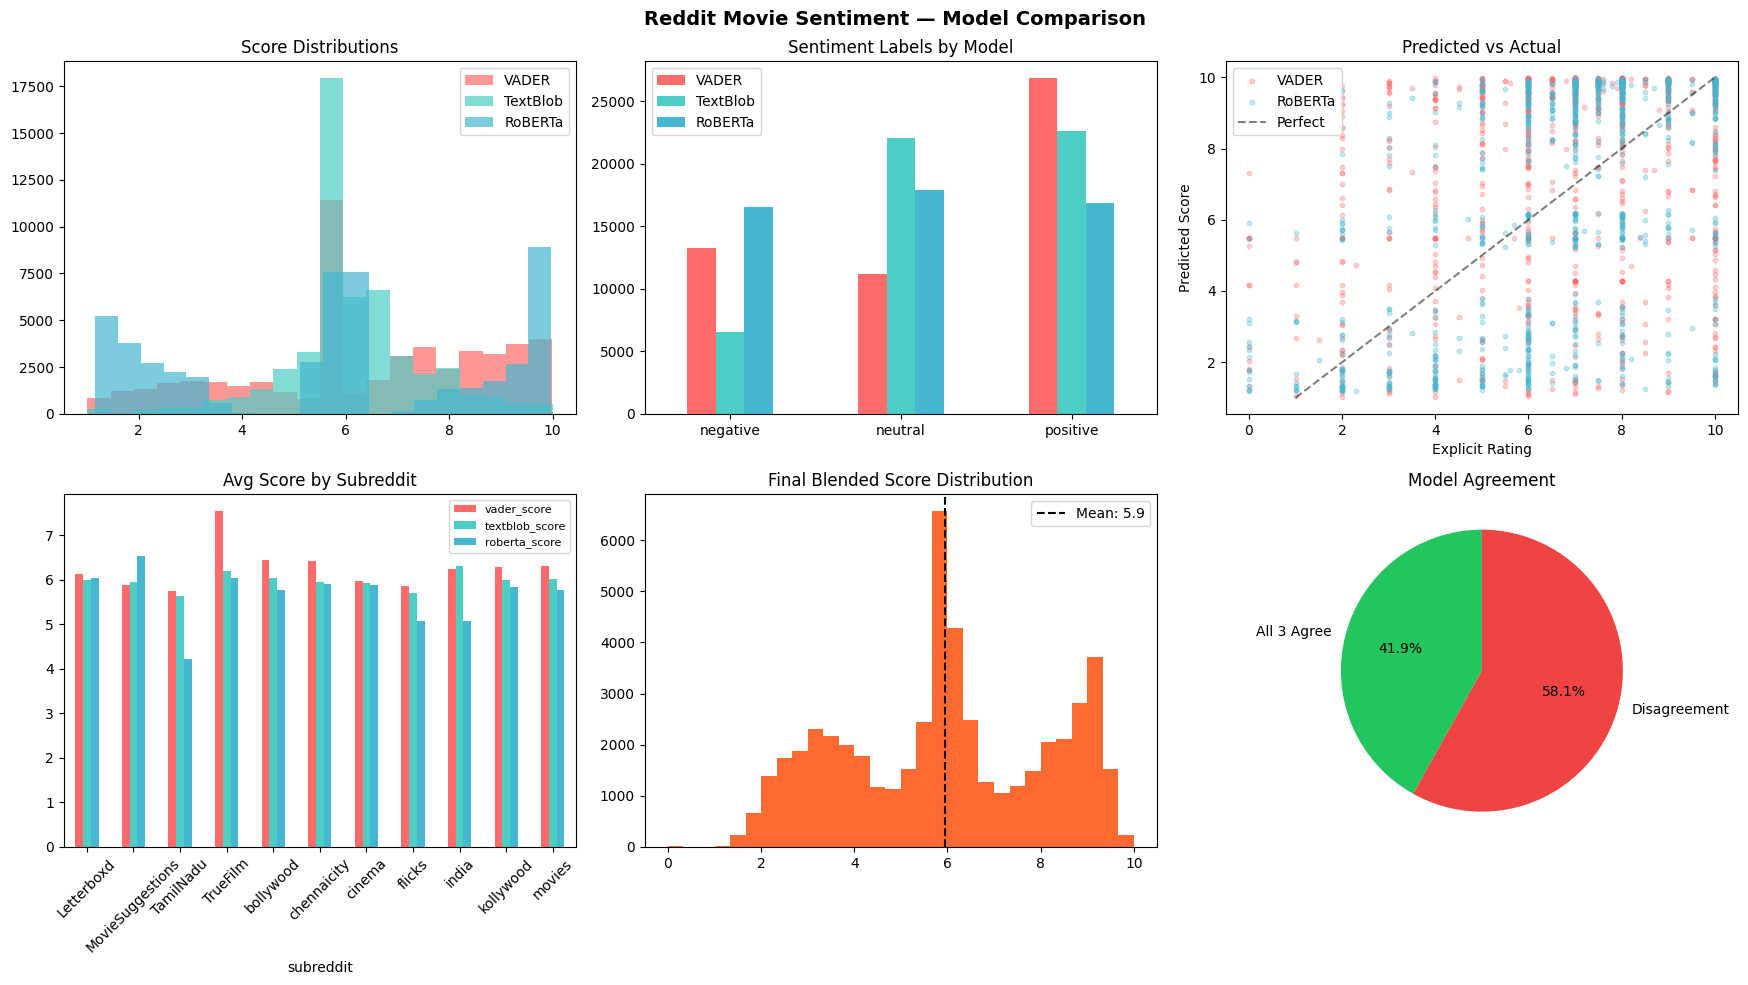

Charts saved!


In [23]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Reddit Movie Sentiment — Model Comparison", fontsize=14, fontweight="bold")

# score distributions
axes[0, 0].hist(df["vader_score"], bins=20, alpha=0.7, color="#FF6B6B", label="VADER")
axes[0, 0].hist(df["textblob_score"], bins=20, alpha=0.7, color="#4ECDC4", label="TextBlob")
axes[0, 0].hist(df["roberta_score"], bins=20, alpha=0.7, color="#45B7D1", label="RoBERTa")
axes[0, 0].set_title("Score Distributions")
axes[0, 0].legend()

# sentiment labels
labels_df = pd.DataFrame({
    "VADER": df["vader_label"].value_counts(),
    "TextBlob": df["textblob_label"].value_counts(),
    "RoBERTa": df["roberta_label"].value_counts()
})
labels_df.plot(kind="bar", ax=axes[0, 1], color=["#FF6B6B", "#4ECDC4", "#45B7D1"])
axes[0, 1].set_title("Sentiment Labels by Model")
axes[0, 1].tick_params(axis="x", rotation=0)

# predicted vs actual
if len(rated) > 0:
    axes[0, 2].scatter(rated["extracted_rating"], rated["vader_score"], alpha=0.3, s=10, c="#FF6B6B", label="VADER")
    axes[0, 2].scatter(rated["extracted_rating"], rated["roberta_score"], alpha=0.3, s=10, c="#45B7D1", label="RoBERTa")
    axes[0, 2].plot([1, 10], [1, 10], "k--", alpha=0.5, label="Perfect")
    axes[0, 2].set_xlabel("Explicit Rating")
    axes[0, 2].set_ylabel("Predicted Score")
    axes[0, 2].set_title("Predicted vs Actual")
    axes[0, 2].legend()

# avg by subreddit
sub_scores = df.groupby("subreddit")[["vader_score", "textblob_score", "roberta_score"]].mean()
sub_scores.plot(kind="bar", ax=axes[1, 0], color=["#FF6B6B", "#4ECDC4", "#45B7D1"])
axes[1, 0].set_title("Avg Score by Subreddit")
axes[1, 0].tick_params(axis="x", rotation=45)
axes[1, 0].legend(fontsize=8)

# final score distribution
axes[1, 1].hist(df["final_score"], bins=30, color="#FF4500", alpha=0.8)
axes[1, 1].set_title("Final Blended Score Distribution")
axes[1, 1].axvline(df["final_score"].mean(), color="black", linestyle="--", label=f"Mean: {df['final_score'].mean():.1f}")
axes[1, 1].legend()

# model agreement
df["all_agree"] = (df["vader_label"] == df["textblob_label"]) & (df["textblob_label"] == df["roberta_label"])
agree_pct = df["all_agree"].mean() * 100
axes[1, 2].pie(
    [agree_pct, 100 - agree_pct],
    labels=["All 3 Agree", "Disagreement"],
    colors=["#22c55e", "#ef4444"],
    autopct="%.1f%%", startangle=90
)
axes[1, 2].set_title("Model Agreement")

plt.tight_layout()
plt.savefig("data/sentiment_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Charts saved!")

## 10. Push to Snowflake (uncomment when ready)

In [25]:
from snowflake.connector.pandas_tools import write_pandas
from dotenv import load_dotenv
import snowflake.connector
import os

load_dotenv()

conn = snowflake.connector.connect(
    user="ATHULYA2303",
    password=os.getenv("SNOWFLAKE_PASSWORD"),
    account="gsc07824.us-east-1",
    warehouse="COMPUTE_WH",
    database="MOVIE_ANALYTICS",
    schema="ANALYTICS"
)

# push comment scores
push_df = df.copy()
push_df.columns = [c.upper() for c in push_df.columns]
write_pandas(conn, push_df, "COMMENT_SCORES_V2",
             database="MOVIE_ANALYTICS", schema="ANALYTICS",
             auto_create_table=True, overwrite=True)

# push movie scores
push_movies = movie_scores.copy()
push_movies.columns = [c.upper() for c in push_movies.columns]
write_pandas(conn, push_movies, "MOVIE_RATINGS_V2",
             database="MOVIE_ANALYTICS", schema="ANALYTICS",
             overwrite=True)

conn.close()
print("Pushed to Snowflake!")

Pushed to Snowflake!


In [26]:
# import pandas as pd
# import snowflake.connector
# from dotenv import load_dotenv
# import os

# load_dotenv()

# conn = snowflake.connector.connect(
#     user="ATHULYA2303",
#     password=os.getenv("SNOWFLAKE_PASSWORD"),
#     account="gsc07824.us-east-1",
#     warehouse="COMPUTE_WH",
#     database="MOVIE_ANALYTICS",
#     schema="RAW"
# )

# df = pd.read_sql("SELECT * FROM RAW.MOVIES_MASTER LIMIT 5", conn)
# print(df.columns.tolist())
# df.head()

## 9. Save Everything

In [27]:
# comment-level data
df.to_csv("data/reddit_sentiment_scored.csv", index=False)
print(f"Saved {len(df)} scored comments to data/reddit_sentiment_scored.csv")

# movie-level scores
movie_scores.to_csv("data/reddit_movie_scores.csv", index=False)
print(f"Saved {len(movie_scores)} movie scores to data/reddit_movie_scores.csv")

print("Done! Next step: join these with OMDB ratings and compare.")

Saved 51298 scored comments to data/reddit_sentiment_scored.csv
Saved 401 movie scores to data/reddit_movie_scores.csv
Done! Next step: join these with OMDB ratings and compare.
